In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.chdir("..")
print(os.getcwd(), os.listdir())

C:\Users\an.v.potapov\Desktop\учеба\ФТИАД\курсач\gan_moex ['.git', '.gitignore', '.idea', '.ipynb_checkpoints', '.pytest_cache', 'AIRI', 'compare with airi', 'dashboard', 'data', 'genrisk', 'library', 'lightning_logs', 'models', 'README.MD', 'research', 'setup.py', 'test.egg-info', 'TSGBench', 'wandb']


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from torch.utils.data import DataLoader
import seaborn as sns
from torch import optim
import torch
import wandb


In [4]:
from library.dataset import get_pytorch_datataset, BATCH_SIZE

df_returns_real, dataset, dataloader, N_ASSETS, WINDOW_SIZE = get_pytorch_datataset()

print(f'\nDataset length: {len(dataset)}')
print(f'Number of assets: {N_ASSETS}')
sample_batch = next(iter(dataloader))
assert sample_batch.size() == (BATCH_SIZE, N_ASSETS, WINDOW_SIZE)
print(f'Sample batch: {sample_batch.size()}')

AAAAAAA data True data\tickers.csv True
Chosen tickers: ['LKOH', 'SBER', 'SBERP', 'VTBR', 'MOEX']
Length before dropping NaNs: 2603
Length after dropping NaNs: 2577

Dataset length: 2217
Number of assets: 5
Sample batch: torch.Size([256, 5, 360])


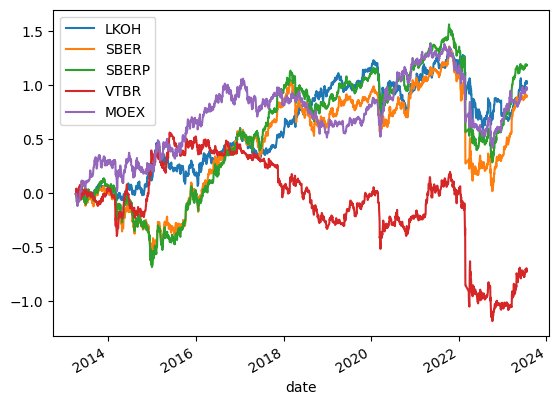

In [5]:
df_returns_real.cumsum().plot()
plt.show()

In [6]:
from genrisk.generation import TCNGAN

<Axes: xlabel='date'>

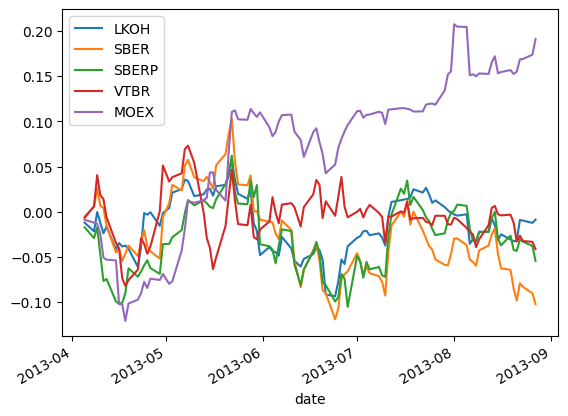

In [32]:
df_returns_real.iloc[:100].cumsum().plot()

In [19]:
torch.save(gen.model.gen.state_dict(), 'models/AIRI/TCN/N_EPOCHS_400_KERNEL_SIZE_5_window_size_360.pth')


In [10]:
wandb.init(
        project="test",  # Название проекта в W&B
        name=f"AIRI генерация log доходности акций",         # Название эксперимента
        
        config={              # Сохраняем гиперпараметры
            "learning_rate": 0.001,
            "batch_size": 0,
            "architecture": "TCN-GAN AIRI",
            "dataset": 'log-returs',
            "N_EPOCHS": 1,
        }
    )
    
test_model = TCNGAN(
    target_columns=df_returns_real.columns.tolist(), 
    conditional_columns=[],
    hidden_dim=16,
    latent_dim=1,
    num_layers=2,
    kernel_size=3,
    num_disc_steps=3,
    window_size=126,
    batch_size=16,
    num_epochs=1,
    verbose=True,
    lr=0.001,
)
test_model.fit(df_returns_real)
wandb.finish()

Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
C:\Python\Lib\site-packages\lightning\pytorch\loggers\wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.

  | Name | Type              | Params | Mode 
---------------------------------------------------
0 | gen  | _TCNGenerator     | 2.5 K  | train
1 | disc | _TCNDiscriminator | 2.7 K  | train
---------------------------------------------------
5.3 K     Trainable params
0         Non-trainable params
5.3 K     Total params
0.021     Total estimated model params size (MB)
24        Modules in train mode
0         Modules in eval mode


Training: |                                                                                                 | …

`Trainer.fit` stopped: `max_epochs=1` reached.


correlation_delta,▆▂▅▂▇█▅▁▅
epoch,▁▁▁▁▁▁▁▁▁
fid,▄▅▅▁▄▁▃█▄
mean_delta,▆▆▆▇█▄▄▃▁
train_disc_loss,▂▁▂▂▃▃▅▇█
train_gen_loss,▁▃▃▅▅▆▇▇█
trainer/global_step,▁▂▃▄▅▅▆▇█
correlation_delta,0.83543
epoch,0
fid,6.50645
mean_delta,0.22838


In [12]:
# torch.save(gen.model.gen.state_dict(), '')
test_model.model.gen.load_state_dict(torch.load('models/AIRI/TCN/test_save.pth'))

<All keys matched successfully>

In [14]:

fake_data = test_model.sample(df_returns_real, n_samples=10)
fake_data[0].head()

,LKOH,SBER,SBERP,VTBR,MOEX
date,,,,,
2013-04-05,0.016270,-0.035804,0.015416,0.066307,0.053003
2013-04-08,-0.005711,-0.028314,0.013687,0.031832,0.014898
2013-04-09,0.014258,0.003238,0.035848,-0.006480,-0.002224
2013-04-10,0.011610,-0.005799,0.018235,-0.000902,-0.007754
2013-04-11,0.003941,0.040849,0.016328,-0.009477,-0.010623


<Figure size 1200x300 with 0 Axes>

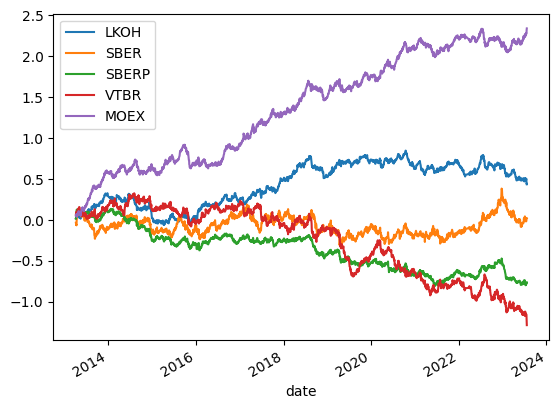

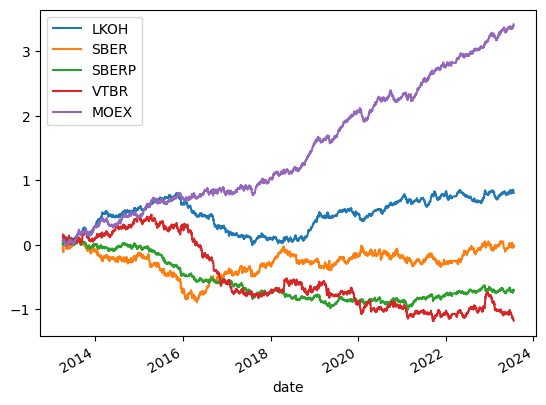

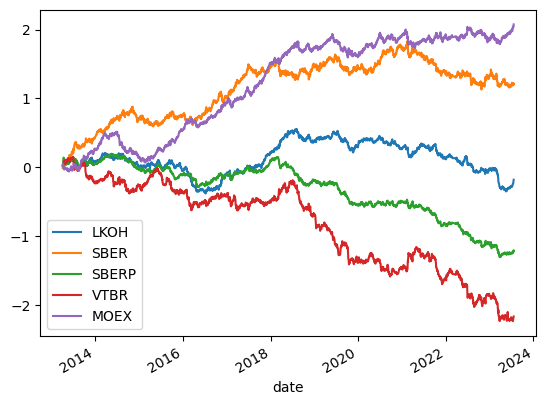

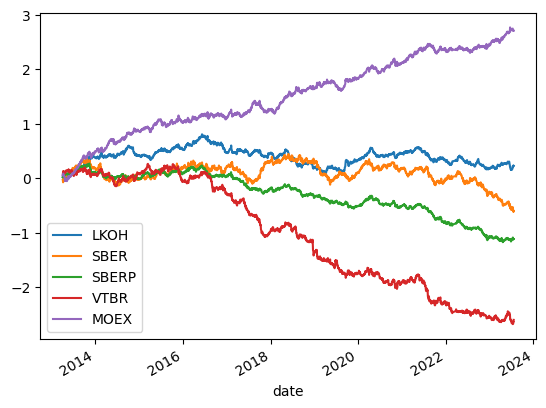

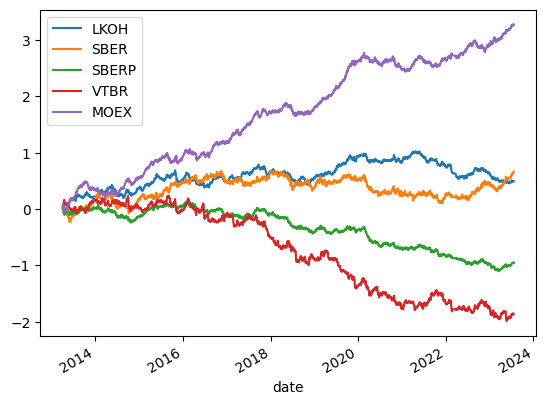

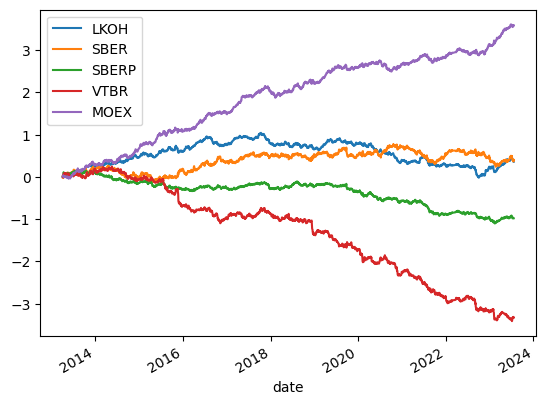

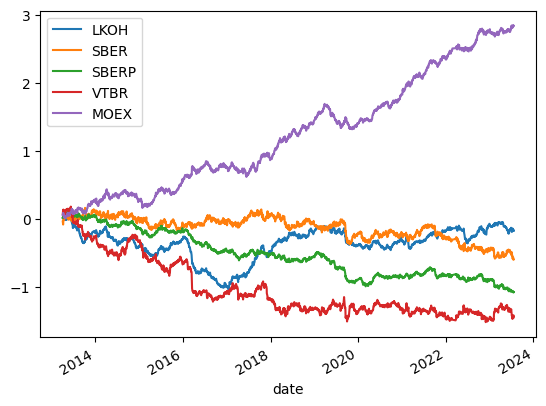

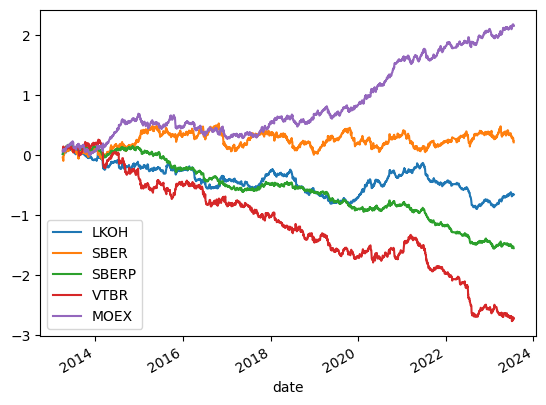

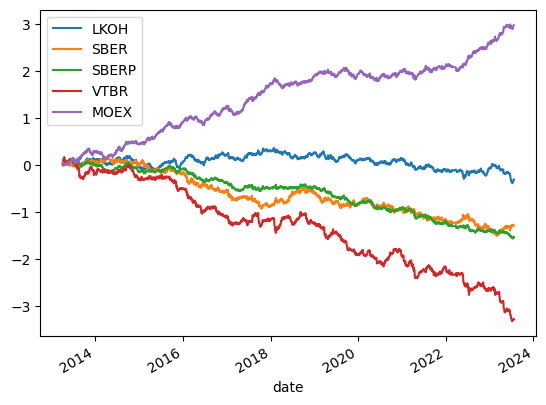

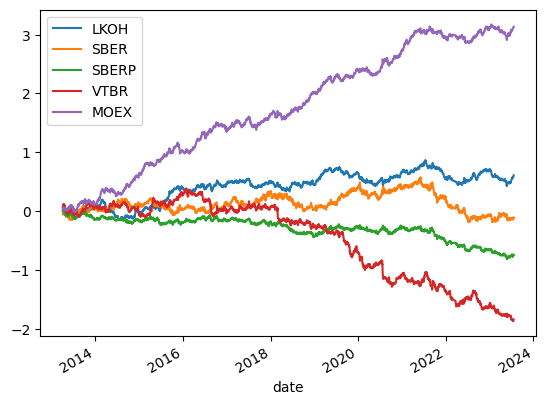

In [15]:
plt.figure(figsize=(12, 3))
for fake in fake_data:
    fake.cumsum().plot()


In [28]:
import torch
import torch.nn.functional as F


def vectorized_autocorrelation(x, lag, window_size):
    """
    Устойчивый расчет автокорреляции для 5D рядов
    Args:
        x: [batch_size, num_assets, seq_len]
        lag: лаг L (должен удовлетворять lag + window_size <= seq_len)
        window_size: N
    Returns:
        [batch_size, num_assets] (усредненная по окнам автокорреляция)
    """

    # 2. Создаем скользящие окна
    windows = x.unfold(2, window_size, 1)  # [batch, assets, num_windows, window_size]  
    
    # 3. Центрирование данных
    windows_centered = windows - windows.mean(dim=3, keepdim=True)
      
    # 4. Вычисление корреляции
    x_t = windows_centered[:, :, 0]
    x_t_lag = windows_centered[:, :, lag]
    # 5. Устойчивые вычисления
    cov = (x_t * x_t_lag).sum(dim=2)
    std_t = torch.norm(x_t, dim=2)
    std_t_lag = torch.norm(x_t_lag, dim=2)
    
    print(std_t * std_t_lag)
    print(cov )
    # 6. Специальная обработка нулевых стандартных отклонений
    autocorr = cov / (std_t * std_t_lag)
    
    return autocorr.mean(axis=0)**2 - (torch.ones((5)) * 0.7)**2

In [29]:
batch_size, num_assets, seq_len = 32, 5, 360
real_data = torch.randn(batch_size, num_assets, seq_len)
fake_data = torch.randn(batch_size, num_assets, seq_len)

# Расчет потерь
corr = vectorized_autocorrelation(real_data, 
                          lag=300, 
                          window_size=65)

print(corr)

IndexError: index 300 is out of bounds for dimension 2 with size 296

In [143]:
(torch.ones((5)) * 0.7)**2

tensor([0.4900, 0.4900, 0.4900, 0.4900, 0.4900])

In [34]:
a = torch.rand(1, 5, 10)
a

tensor([[[0.5507, 0.0541, 0.0273, 0.8446, 0.9515, 0.8564, 0.8077, 0.4318,
          0.1164, 0.7927],
         [0.0427, 0.7924, 0.7051, 0.2843, 0.3155, 0.5688, 0.6870, 0.8845,
          0.9254, 0.0838],
         [0.0120, 0.4428, 0.5890, 0.3189, 0.1533, 0.1292, 0.6010, 0.8147,
          0.0045, 0.7844],
         [0.5150, 0.9998, 0.0719, 0.8070, 0.7048, 0.3863, 0.1865, 0.5696,
          0.6289, 0.9904],
         [0.7923, 0.4406, 0.1700, 0.5278, 0.2688, 0.7421, 0.6236, 0.8011,
          0.2801, 0.8729]]])

In [38]:
x = a.unfold(dimension=2, size=5, step=1)
x.shape

torch.Size([1, 5, 6, 5])

In [39]:
x

tensor([[[[0.5507, 0.0541, 0.0273, 0.8446, 0.9515],
          [0.0541, 0.0273, 0.8446, 0.9515, 0.8564],
          [0.0273, 0.8446, 0.9515, 0.8564, 0.8077],
          [0.8446, 0.9515, 0.8564, 0.8077, 0.4318],
          [0.9515, 0.8564, 0.8077, 0.4318, 0.1164],
          [0.8564, 0.8077, 0.4318, 0.1164, 0.7927]],

         [[0.0427, 0.7924, 0.7051, 0.2843, 0.3155],
          [0.7924, 0.7051, 0.2843, 0.3155, 0.5688],
          [0.7051, 0.2843, 0.3155, 0.5688, 0.6870],
          [0.2843, 0.3155, 0.5688, 0.6870, 0.8845],
          [0.3155, 0.5688, 0.6870, 0.8845, 0.9254],
          [0.5688, 0.6870, 0.8845, 0.9254, 0.0838]],

         [[0.0120, 0.4428, 0.5890, 0.3189, 0.1533],
          [0.4428, 0.5890, 0.3189, 0.1533, 0.1292],
          [0.5890, 0.3189, 0.1533, 0.1292, 0.6010],
          [0.3189, 0.1533, 0.1292, 0.6010, 0.8147],
          [0.1533, 0.1292, 0.6010, 0.8147, 0.0045],
          [0.1292, 0.6010, 0.8147, 0.0045, 0.7844]],

         [[0.5150, 0.9998, 0.0719, 0.8070, 0.7048],
      

In [78]:
a[..., 2:].unfold(dimension=2, size=2, step=3)

tensor([[[[0.1807, 0.0803],
          [0.3877, 0.6295],
          [0.5227, 0.7892]]]])